<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 50px 40px; border-radius: 16px; text-align: center; margin-bottom: 30px;">
  <h1 style="color: #e94560; font-size: 2.8em; font-weight: 800; margin: 0; letter-spacing: 2px;">🤖 TASK 6</h1>
  <h2 style="color: #ffffff; font-size: 2em; font-weight: 600; margin: 10px 0;">Question Answering with Transformers</h2>
  <p style="color: #a8b2d8; font-size: 1.1em; margin-top: 15px;">SQuAD v1.1 · BERT · DistilBERT · RoBERTa · ALBERT · F1 Evaluation</p>
  <div style="margin-top: 20px;">
    <span style="background: #e94560; color: white; padding: 6px 18px; border-radius: 20px; font-size: 0.85em; font-weight: 600; margin: 4px;">HuggingFace Transformers</span>
    <span style="background: #0f3460; color: #a8b2d8; padding: 6px 18px; border-radius: 20px; font-size: 0.85em; border: 1px solid #e94560; margin: 4px;">Span Extraction</span>
    <span style="background: #0f3460; color: #a8b2d8; padding: 6px 18px; border-radius: 20px; font-size: 0.85em; border: 1px solid #e94560; margin: 4px;">NLP Benchmarking</span>
  </div>
</div>

## 📋 Table of Contents

| # | Section |
|---|--------|
| 1 | Install Dependencies |
| 2 | Imports & Global Config |
| 3 | Dataset Loading & EDA |
| 4 | Dataset Visualisation |
| 5 | Universal QA Loader |
| 6 | Load All 4 Models |
| 7 | Inference on Sample Examples |
| 8 | Evaluation — EM & F1 |
| 9 | Benchmark All Models |
| 10 | Interactive Demo |
| 11 | Final Dashboard & Conclusions |

---
## ⚙️ Cell 1 — Install Dependencies

In [1]:
import subprocess, sys

packages = [
    "transformers>=4.35.0",
    "datasets>=2.14.0",
    "torch>=2.0.0",
    "pandas>=2.0.0",
    "numpy>=1.24.0",
    "matplotlib>=3.7.0",
    "seaborn>=0.12.0",
    "tqdm>=4.65.0",
    "scikit-learn>=1.3.0",
    "ipywidgets>=8.0.0",
]

for pkg in packages:
    name = pkg.split('>=')[0]
    print(f"📦 Installing {name}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("\n✅ All packages installed. Proceed to Cell 2.")

📦 Installing transformers...
📦 Installing datasets...
📦 Installing torch...
📦 Installing pandas...
📦 Installing numpy...
📦 Installing matplotlib...
📦 Installing seaborn...
📦 Installing tqdm...
📦 Installing scikit-learn...
📦 Installing ipywidgets...

✅ All packages installed. Proceed to Cell 2.


---
## 🔧 Cell 2 — Imports & Global Config

In [2]:
# ── Standard Library ─────────────────────────────────────────
import os, re, json, time, string, warnings
from collections import Counter

# ── Data & Math ──────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── HuggingFace ──────────────────────────────────────────────
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import torch

# ── Progress & Display ───────────────────────────────────────
from tqdm.auto import tqdm
from IPython.display import display, HTML
import ipywidgets as widgets

warnings.filterwarnings("ignore")

# ── Plot Theme ───────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#c9d1d9",
    "grid.color":       "#21262d",
    "grid.linestyle":   "--",
    "font.family":      "monospace",
    "axes.titlesize":   14,
    "axes.labelsize":   11,
})
PALETTE = ["#e94560", "#00d4ff", "#7ee787", "#ffa657", "#d2a8ff", "#f78166"]

# ── Device ───────────────────────────────────────────────────
DEVICE      = 0 if torch.cuda.is_available() else -1
DEVICE_NAME = "CUDA GPU" if DEVICE == 0 else "CPU"
TORCH_DEV   = torch.device("cuda" if DEVICE == 0 else "cpu")

display(HTML(f"""
<div style='background:#161b22; border:1px solid #30363d; border-left:4px solid #e94560;
            padding:16px 20px; border-radius:8px; font-family:monospace;'>
  <b style='color:#e94560;'>✅ Cell 2 Complete — Environment Ready</b><br><br>
  <span style='color:#7ee787;'>PyTorch</span>  : {torch.__version__}<br>
  <span style='color:#7ee787;'>Device</span>   : <b style='color:#ffa657;'>{DEVICE_NAME}</b><br>
  <span style='color:#7ee787;'>NumPy</span>    : {np.__version__}<br>
  <span style='color:#7ee787;'>Pandas</span>   : {pd.__version__}
</div>
"""))

---
## 📂 Cell 3 — Load SQuAD v1.1 Dataset

In [3]:
print("⏳ Loading SQuAD v1.1 from HuggingFace Datasets...")
squad    = load_dataset("squad")
train_ds = squad["train"]
val_ds   = squad["validation"]

print(f"✅ Train   : {len(train_ds):,} examples")
print(f"✅ Val     : {len(val_ds):,} examples")
print(f"\nFeatures  : {list(train_ds.features.keys())}")

# ── Sample Records Preview ───────────────────────────────────
sample_rows = []
for i in range(5):
    ex = train_ds[i]
    sample_rows.append({
        "title":    ex["title"],
        "question": ex["question"],
        "answer":   ex["answers"]["text"][0],
        "ctx_len":  len(ex["context"]),
    })
pd.set_option("display.max_colwidth", 55)
display(pd.DataFrame(sample_rows))

# ── Pretty Example Renderer ──────────────────────────────────
def display_qa_example(example, idx=0):
    ctx   = example["context"]
    q     = example["question"]
    ans   = example["answers"]["text"][0]
    start = example["answers"]["answer_start"][0]
    end   = start + len(ans)
    ctx_html = (
        ctx[:start]
        + f"<mark style='background:#e94560;color:#fff;padding:2px 4px;border-radius:3px;'>{ans}</mark>"
        + ctx[end:]
    )
    display(HTML(f"""
    <div style='background:#161b22;border:1px solid #30363d;padding:18px;
                border-radius:10px;font-family:sans-serif;margin:8px 0;'>
      <div style='color:#8b949e;font-size:0.8em;margin-bottom:8px;'>Example #{idx} · {example['title']}</div>
      <div style='background:#21262d;padding:12px;border-radius:6px;
                  color:#c9d1d9;font-size:0.88em;line-height:1.6;margin-bottom:12px;'>
        {ctx_html[:600]}{'…' if len(ctx)>600 else ''}
      </div>
      <div style='display:flex;gap:20px;flex-wrap:wrap;'>
        <div style='flex:1;'>
          <span style='color:#7ee787;font-weight:700;font-size:0.85em;'>❓ QUESTION</span>
          <p style='color:#c9d1d9;margin:4px 0 0;'>{q}</p>
        </div>
        <div style='flex:1;'>
          <span style='color:#e94560;font-weight:700;font-size:0.85em;'>✅ ANSWER</span>
          <p style='color:#ffa657;margin:4px 0 0;font-weight:600;'>{ans}</p>
        </div>
      </div>
    </div>
    """))

for i in [0, 42, 200]:
    display_qa_example(train_ds[i], idx=i)

⏳ Loading SQuAD v1.1 from HuggingFace Datasets...


✅ Train   : 87,599 examples
✅ Val     : 10,570 examples

Features  : ['id', 'title', 'context', 'question', 'answers']


,title,question,answer,ctx_len
0,University_of_Notre_Dame,To whom did the Virgin Mary allegedly appear in 185...,Saint Bernadette Soubirous,695
1,University_of_Notre_Dame,What is in front of the Notre Dame Main Building?,a copper statue of Christ,695
2,University_of_Notre_Dame,The Basilica of the Sacred heart at Notre Dame is b...,the Main Building,695
3,University_of_Notre_Dame,What is the Grotto at Notre Dame?,a Marian place of prayer and reflection,695
4,University_of_Notre_Dame,What sits on top of the Main Building at Notre Dame?,a golden statue of the Virgin Mary,695


---
## 📊 Cell 4 — Dataset Visualisation

Building stats:   0%|          | 0/3000 [00:00<?, ?it/s]

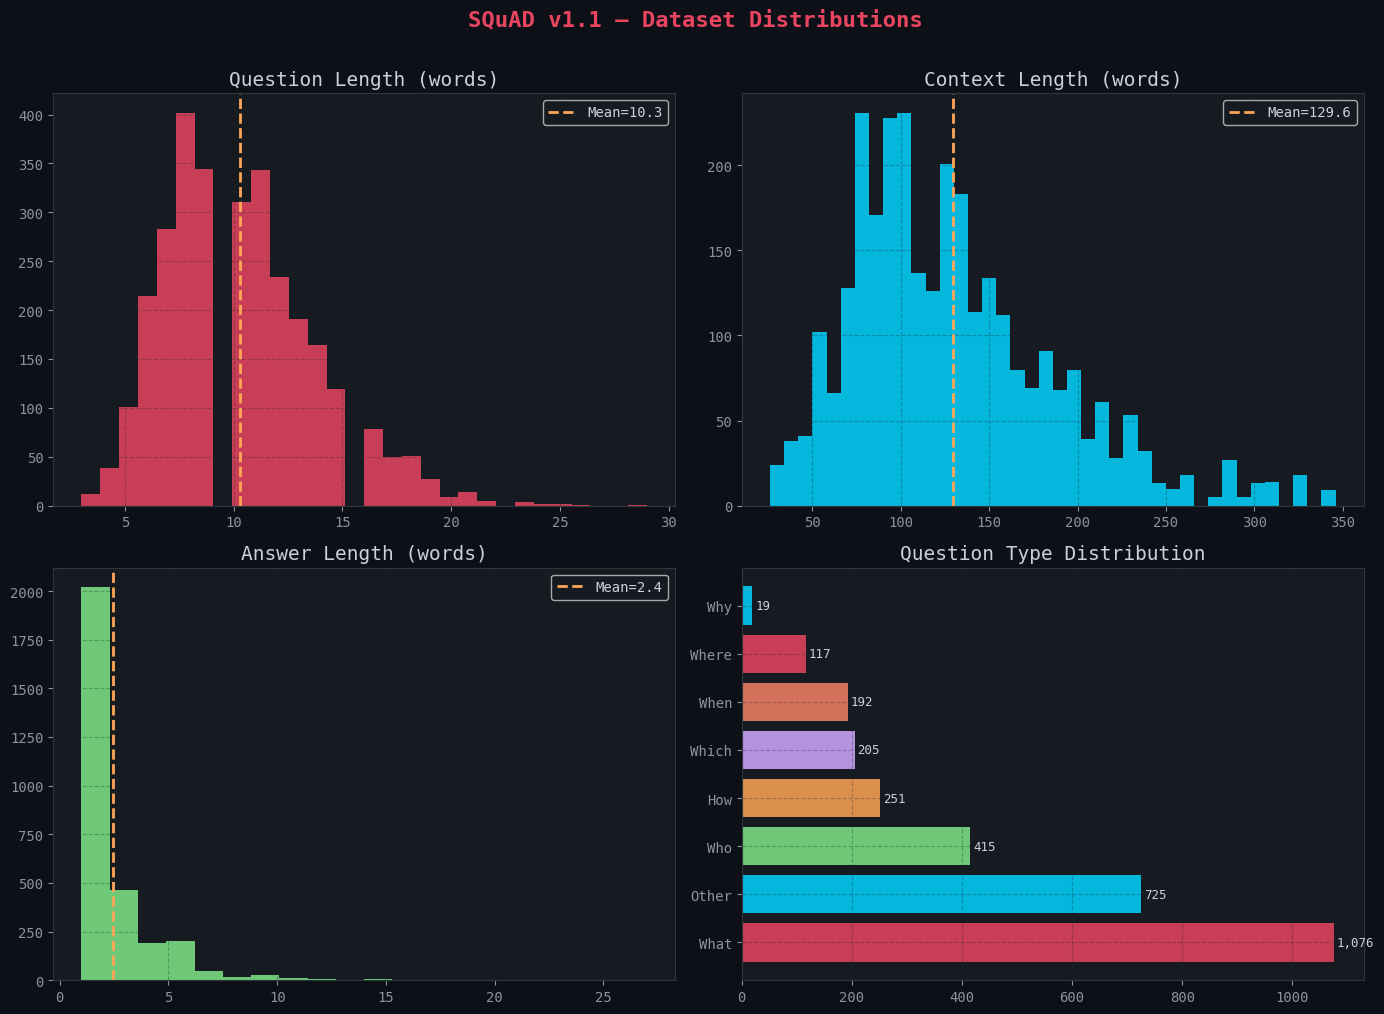

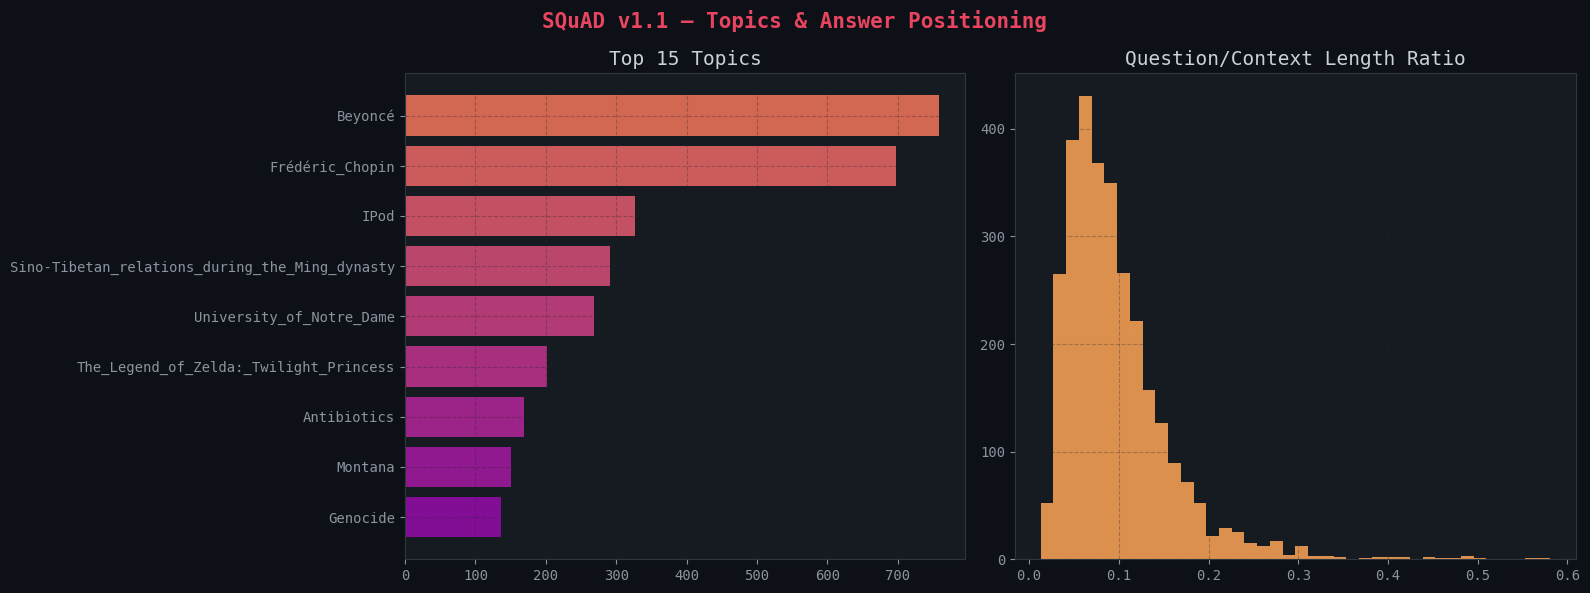

✅ Cell 4 complete.


In [4]:
# ── Build Analysis DataFrame ─────────────────────────────────
N_SAMPLE = 3000
rows = []
for ex in tqdm(train_ds.select(range(N_SAMPLE)), desc="Building stats"):
    fw = ex["question"].strip().lower().split()[0]
    qt_map = {"what":"What","who":"Who","when":"When","where":"Where",
               "how":"How","why":"Why","which":"Which"}
    rows.append({
        "q_len":   len(ex["question"].split()),
        "ctx_len": len(ex["context"].split()),
        "ans_len": len(ex["answers"]["text"][0].split()),
        "title":   ex["title"],
        "q_type":  qt_map.get(fw, "Other"),
    })
df_stats = pd.DataFrame(rows)

# ── Figure 1: Distributions ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("SQuAD v1.1 — Dataset Distributions", fontsize=16,
             color="#e94560", fontweight="bold", y=1.01)

axes[0,0].hist(df_stats["q_len"],  bins=30, color=PALETTE[0], alpha=0.85, edgecolor="none")
axes[0,0].axvline(df_stats["q_len"].mean(), color="#ffa657", lw=2, linestyle="--",
                   label=f"Mean={df_stats['q_len'].mean():.1f}")
axes[0,0].set_title("Question Length (words)", color="#c9d1d9")
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].hist(df_stats["ctx_len"], bins=40, color=PALETTE[1], alpha=0.85, edgecolor="none")
axes[0,1].axvline(df_stats["ctx_len"].mean(), color="#ffa657", lw=2, linestyle="--",
                   label=f"Mean={df_stats['ctx_len'].mean():.1f}")
axes[0,1].set_title("Context Length (words)", color="#c9d1d9")
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[1,0].hist(df_stats["ans_len"], bins=20, color=PALETTE[2], alpha=0.85, edgecolor="none")
axes[1,0].axvline(df_stats["ans_len"].mean(), color="#ffa657", lw=2, linestyle="--",
                   label=f"Mean={df_stats['ans_len'].mean():.1f}")
axes[1,0].set_title("Answer Length (words)", color="#c9d1d9")
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

qt = df_stats["q_type"].value_counts()
bars = axes[1,1].barh(qt.index, qt.values, color=PALETTE[:len(qt)], alpha=0.85)
for bar, val in zip(bars, qt.values):
    axes[1,1].text(val+5, bar.get_y()+bar.get_height()/2,
                   f"{val:,}", va="center", color="#c9d1d9", fontsize=9)
axes[1,1].set_title("Question Type Distribution", color="#c9d1d9")
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Figure 2: Top Topics ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("SQuAD v1.1 — Topics & Answer Positioning",
             fontsize=15, color="#e94560", fontweight="bold")

top_topics  = df_stats["title"].value_counts().head(15)
colors_bar  = plt.cm.plasma(np.linspace(0.3, 0.9, 15))
axes[0].barh(top_topics.index[::-1], top_topics.values[::-1], color=colors_bar, alpha=0.9)
axes[0].set_title("Top 15 Topics", color="#c9d1d9")
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_stats["q_len"] / df_stats["ctx_len"].clip(1),
             bins=40, color=PALETTE[3], alpha=0.85, edgecolor="none")
axes[1].set_title("Question/Context Length Ratio", color="#c9d1d9")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Cell 4 complete.")

---
## 🔩 Cell 5 — Universal QA Model Loader
> **Must run before Cell 6.** Defines `load_qa_model()` used by all model cells.

In [5]:
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    AlbertTokenizer,          # ← slow tokenizer, bypasses AutoTokenizer routing
)
import torch, subprocess, sys

# Install required backends
for pkg in ["sentencepiece", "protobuf"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("✅ sentencepiece + protobuf installed")

# Map model_name → specific tokenizer class to use
# (None = use AutoTokenizer, which works fine for BERT/RoBERTa/DistilBERT)
TOKENIZER_CLASS_OVERRIDE = {
    "twmkn9/albert-base-v2-squad2": AlbertTokenizer,
}

def load_qa_model(model_name, device_obj=None):
    """
    Loads any HuggingFace QA model safely.
    Uses model-specific tokenizer classes where AutoTokenizer fails.
    Compatible with transformers v4.35–v4.52+.
    """
    if device_obj is None:
        device_obj = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Pick the right tokenizer class
    tok_class = TOKENIZER_CLASS_OVERRIDE.get(model_name, None)

    print(f"   ↳ Tokenizer ({'specific class' if tok_class else 'AutoTokenizer'})...")
    if tok_class is not None:
        tok = tok_class.from_pretrained(model_name)
    else:
        tok = AutoTokenizer.from_pretrained(model_name)

    print(f"   ↳ Model weights...")
    mdl = AutoModelForQuestionAnswering.from_pretrained(model_name)
    mdl = mdl.to(device_obj)
    mdl.eval()

    def qa_fn(question, context, max_answer_len=100, **kwargs):
        inputs = tok(
            question, context,
            return_tensors="pt",
            truncation=True,
            max_length=512,
            padding=True,
        )
        inputs = {k: v.to(device_obj) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = mdl(**inputs)

        start_probs = torch.softmax(outputs.start_logits[0], dim=-1)
        end_probs   = torch.softmax(outputs.end_logits[0],   dim=-1)

        best_score, best_start, best_end = -1, 0, 0
        for s in range(len(start_probs)):
            for e in range(s, min(s + max_answer_len, len(end_probs))):
                score = start_probs[s].item() * end_probs[e].item()
                if score > best_score:
                    best_score, best_start, best_end = score, s, e

        answer = tok.decode(
            inputs["input_ids"][0][best_start: best_end + 1],
            skip_special_tokens=True
        )
        return {"answer": answer, "score": best_score,
                "start": best_start, "end": best_end}

    return qa_fn


display(HTML("""
<div style='background:#161b22; border:1px solid #7ee787; border-left:4px solid #7ee787;
            padding:14px 18px; border-radius:8px; font-family:monospace;'>
  <b style='color:#7ee787;'>✅ load_qa_model() ready</b><br><br>
  <span style='color:#c9d1d9;'>DistilBERT / BERT / RoBERTa</span>
  <span style='color:#8b949e;'> → AutoTokenizer (fast)</span><br>
  <span style='color:#c9d1d9;'>ALBERT</span>
  <span style='color:#8b949e;'> → AlbertTokenizer (slow, SentencePiece)</span>
</div>
"""))

✅ sentencepiece + protobuf installed


---
## 🤖 Cell 6 — Load All 4 Models + Registry
> Requires Cell 2 (TORCH_DEV) and Cell 5 (load_qa_model) to be run first.

In [6]:
import time

# ── Model definitions ────────────────────────────────────────
MODEL_REGISTRY = {
    "DistilBERT": {
        "model":       "distilbert-base-cased-distilled-squad",
        "description": "66M params · 40% smaller · 60% faster than BERT",
        "color":       "#00d4ff",
    },
    "BERT-Large": {
        "model":       "bert-large-uncased-whole-word-masking-finetuned-squad",
        "description": "340M params · Bidirectional · WWM pre-training",
        "color":       "#e94560",
    },
    "RoBERTa": {
        "model":       "deepset/roberta-base-squad2",
        "description": "125M params · Robustly optimised BERT",
        "color":       "#7ee787",
    },
    "ALBERT": {
        "model":       "twmkn9/albert-base-v2-squad2",
        "description": "12M params · Parameter sharing · Lite BERT",
        "color":       "#ffa657",
    },
}

# ── Load each model ──────────────────────────────────────────
load_times = {}
for name, info in MODEL_REGISTRY.items():
    print(f"\n⏳ [{name}] Loading {info['model']}...")
    t0 = time.time()
    MODEL_REGISTRY[name]["pipeline"] = load_qa_model(info["model"], device_obj=TORCH_DEV)
    load_times[name] = time.time() - t0
    print(f"   ✅ {name} loaded in {load_times[name]:.1f}s")

# ── Convenience aliases ──────────────────────────────────────
qa_distilbert = MODEL_REGISTRY["DistilBERT"]["pipeline"]
qa_bert       = MODEL_REGISTRY["BERT-Large"]["pipeline"]
qa_roberta    = MODEL_REGISTRY["RoBERTa"]["pipeline"]
qa_albert     = MODEL_REGISTRY["ALBERT"]["pipeline"]

print("\n" + "─"*55)
print("  ALL MODELS LOADED")
print("─"*55)

# ── Registry display table ───────────────────────────────────
rows_html = ""
for name, info in MODEL_REGISTRY.items():
    rows_html += f"""
    <tr>
      <td style='padding:9px 12px;'><b style='color:{info['color']};'>{name}</b></td>
      <td style='padding:9px 12px;color:#8b949e;font-size:0.85em;'>{info['model']}</td>
      <td style='padding:9px 12px;color:#c9d1d9;font-size:0.85em;'>{info['description']}</td>
      <td style='padding:9px 12px;color:#ffa657;font-size:0.85em;'>{load_times[name]:.1f}s</td>
    </tr>"""

display(HTML(f"""
<div style='background:#161b22;border:1px solid #30363d;padding:20px;border-radius:10px;margin-top:12px;'>
  <h3 style='color:#e94560;margin-top:0;'>🧪 Model Registry — All Loaded</h3>
  <table style='width:100%;border-collapse:collapse;font-family:monospace;'>
    <tr style='background:#21262d;'>
      <th style='padding:10px;text-align:left;color:#7ee787;'>Name</th>
      <th style='padding:10px;text-align:left;color:#7ee787;'>HuggingFace ID</th>
      <th style='padding:10px;text-align:left;color:#7ee787;'>Notes</th>
      <th style='padding:10px;text-align:left;color:#7ee787;'>Load Time</th>
    </tr>
    {rows_html}
  </table>
</div>
"""))

# ── Sanity check ─────────────────────────────────────────────
test_q   = "Who invented the telephone?"
test_ctx = "Alexander Graham Bell is credited with inventing the telephone in 1876."

display(HTML("<h4 style='color:#ffa657;font-family:monospace;margin-top:18px;'>🧪 Sanity Check</h4>"))
for name, info in MODEL_REGISTRY.items():
    result = info["pipeline"](question=test_q, context=test_ctx)
    color  = info["color"]
    display(HTML(f"""
    <div style='background:#161b22;border-left:4px solid {color};padding:10px 16px;
                border-radius:6px;margin:4px 0;font-family:monospace;font-size:0.9em;'>
      <b style='color:{color};'>{name}</b>
      <span style='color:#8b949e;'> → </span>
      <span style='color:#ffa657;font-weight:700;'>{result['answer']}</span>
      <span style='color:#8b949e;float:right;'>score: {result['score']:.4f}</span>
    </div>
    """))


⏳ [DistilBERT] Loading distilbert-base-cased-distilled-squad...
   ↳ Tokenizer (AutoTokenizer)...
   ↳ Model weights...


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

   ✅ DistilBERT loaded in 3.2s

⏳ [BERT-Large] Loading bert-large-uncased-whole-word-masking-finetuned-squad...
   ↳ Tokenizer (AutoTokenizer)...
   ↳ Model weights...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-large-uncased-whole-word-masking-finetuned-squad
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

pytorch_model.bin:   0%|          | 0.00/46.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForQuestionAnswering LOAD REPORT from: twmkn9/albert-base-v2-squad2
Key                  | Status     |  | 
---------------------+------------+--+-
albert.pooler.bias   | UNEXPECTED |  | 
albert.pooler.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   ✅ ALBERT loaded in 41.2s

───────────────────────────────────────────────────────
  ALL MODELS LOADED
───────────────────────────────────────────────────────


Name,HuggingFace ID,Notes,Load Time
DistilBERT,distilbert-base-cased-distilled-squad,66M params · 40% smaller · 60% faster than BERT,3.2s
BERT-Large,bert-large-uncased-whole-word-masking-finetuned-squad,340M params · Bidirectional · WWM pre-training,2.9s
RoBERTa,deepset/roberta-base-squad2,125M params · Robustly optimised BERT,2.1s
ALBERT,twmkn9/albert-base-v2-squad2,12M params · Parameter sharing · Lite BERT,41.2s


---
## 💬 Cell 7 — Inference on Sample Examples

In [7]:
import time
from IPython.display import display, HTML

sample_examples = [
    {
        "context": """The Apollo program was the third United States human spaceflight
program carried out by NASA. Apollo 11 was the first mission to land on the Moon,
on July 20, 1969. Commander Neil Armstrong and lunar module pilot Buzz Aldrin
landed the Apollo Lunar Module Eagle on the lunar surface.""",
        "question": "When did Apollo 11 land on the Moon?"
    },
    {
        "context": """The Python programming language was created by Guido van Rossum
and first released in 1991. Python emphasizes code readability and supports
multiple programming paradigms including object-oriented and functional programming.""",
        "question": "Who created the Python programming language?"
    },
    {
        "context": """The Great Wall of China is a series of fortifications built along
the historical northern borders of China. The wall stretches approximately
21,196 km (13,171 miles) and was built over many centuries.""",
        "question": "How long is the Great Wall of China?"
    },
    {
        "context": """Marie Curie was a Polish physicist and chemist who conducted pioneering
research on radioactivity. She was the first person to win the Nobel Prize twice,
winning in Physics (1903) and Chemistry (1911).""",
        "question": "How many Nobel Prizes did Marie Curie win?"
    },
]

def render_result(res, model_name, color="#e94560"):
    conf_pct = res["score"] * 100
    display(HTML(f"""
    <div style='background:#161b22;border:1px solid #30363d;padding:18px 20px;
                border-radius:10px;margin:8px 0;font-family:sans-serif;'>
      <div style='display:flex;justify-content:space-between;'>
        <span style='color:#8b949e;font-size:0.8em;'>Model: <b style='color:{color};'>{model_name}</b></span>
        <span style='color:#8b949e;font-size:0.8em;'>⏱ {res['latency']*1000:.1f} ms</span>
      </div>
      <p style='color:#7ee787;font-weight:700;font-size:0.85em;margin:10px 0 4px;'>❓ QUESTION</p>
      <p style='color:#c9d1d9;margin:0 0 12px;'>{res['question']}</p>
      <p style='color:{color};font-weight:700;font-size:0.85em;margin:0 0 4px;'>💡 ANSWER</p>
      <p style='color:#ffa657;font-size:1.1em;font-weight:700;margin:0 0 12px;'>{res['answer']}</p>
      <p style='color:#8b949e;font-size:0.8em;margin:0 0 4px;'>Confidence: {conf_pct:.1f}%</p>
      <div style='background:#21262d;border-radius:4px;height:8px;width:100%;'>
        <div style='background:{color};height:100%;width:{int(conf_pct)}%;border-radius:4px;'></div>
      </div>
    </div>
    """))

# Run all 4 models on all examples
all_results = {}
for name, info in MODEL_REGISTRY.items():
    results = []
    for ex in tqdm(sample_examples, desc=f"{name} inference"):
        t0  = time.time()
        out = info["pipeline"](question=ex["question"], context=ex["context"])
        results.append({**out, "latency": time.time()-t0, **ex})
    all_results[name] = results

# Display results per model
for name, info in MODEL_REGISTRY.items():
    display(HTML(f"<h3 style='color:{info['color']};font-family:monospace;margin-top:20px;'>🤖 {name}</h3>"))
    for r in all_results[name]:
        render_result(r, name, color=info["color"])

DistilBERT inference:   0%|          | 0/4 [00:00<?, ?it/s]

BERT-Large inference:   0%|          | 0/4 [00:00<?, ?it/s]

RoBERTa inference:   0%|          | 0/4 [00:00<?, ?it/s]

ALBERT inference:   0%|          | 0/4 [00:00<?, ?it/s]

---
## 📐 Cell 8 — Evaluation: Exact Match & F1 Score

🔍 Evaluating DistilBERT and BERT-Large on 200 examples...



Eval [DistilBERT]:   0%|          | 0/200 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/46.7M [00:00<?, ?B/s]

Eval [BERT-Large]:   0%|          | 0/200 [00:00<?, ?it/s]

Model,Exact Match %,F1 Score %,Avg Latency (ms)
DistilBERT,75.50,83.18,142.4
BERT-Large,84.00,90.92,152.1


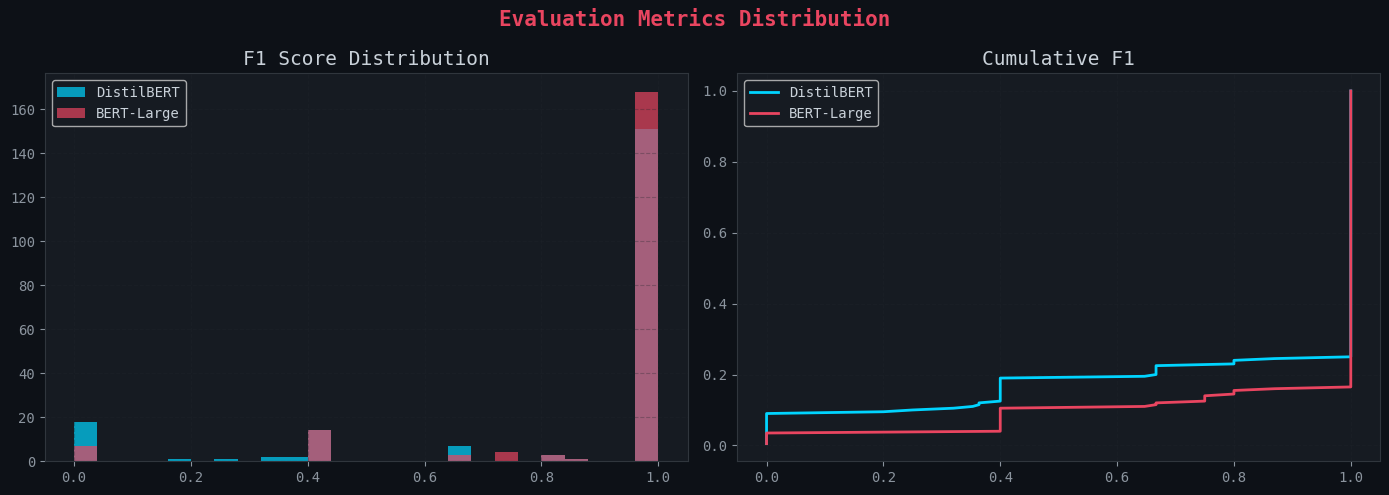

✅ Cell 8 complete.


In [8]:
import re, string, time
import numpy as np
from collections import Counter
from tqdm.auto import tqdm
from IPython.display import display, HTML

# ── Metric Functions ─────────────────────────────────────────
def normalize_answer(s):
    def remove_articles(t): return re.sub(r"\b(a|an|the)\b", " ", t)
    def white_space_fix(t): return " ".join(t.split())
    def remove_punc(t):
        excl = set(string.punctuation)
        return "".join(ch for ch in t if ch not in excl)
    return white_space_fix(remove_articles(remove_punc(s.lower())))

def exact_match_score(pred, gt):
    return int(normalize_answer(pred) == normalize_answer(gt))

def f1_score(pred, gt):
    p_toks = normalize_answer(pred).split()
    g_toks = normalize_answer(gt).split()
    common = Counter(p_toks) & Counter(g_toks)
    n_same = sum(common.values())
    if n_same == 0: return 0.0
    prec = n_same / len(p_toks)
    rec  = n_same / len(g_toks)
    return 2 * prec * rec / (prec + rec)

def evaluate_model(qa_fn, examples, desc="Model"):
    """Evaluate any qa_fn callable on SQuAD examples. Returns dict of metrics."""
    em_list, f1_list, lat_list = [], [], []
    for ex in tqdm(examples, desc=f"Eval [{desc}]"):
        t0   = time.time()
        out  = qa_fn(question=ex["question"], context=ex["context"])
        lat  = time.time() - t0
        pred = out["answer"]
        gts  = ex["answers"]["text"]
        em_list.append(max(exact_match_score(pred, gt) for gt in gts))
        f1_list.append(max(f1_score(pred, gt)          for gt in gts))
        lat_list.append(lat)
    return {
        "EM":             np.mean(em_list) * 100,
        "F1":             np.mean(f1_list) * 100,
        "Avg_Latency_ms": np.mean(lat_list) * 1000,
        "em_list":        em_list,
        "f1_list":        f1_list,
    }

# ── Run Evaluation (DistilBERT + BERT only for Section 8 plot) ─
N_EVAL        = 200
eval_examples = [val_ds[i] for i in range(N_EVAL)]

print(f"🔍 Evaluating DistilBERT and BERT-Large on {N_EVAL} examples...\n")
metrics_distilbert = evaluate_model(qa_distilbert, eval_examples, "DistilBERT")
metrics_bert       = evaluate_model(qa_bert,       eval_examples, "BERT-Large")

display(HTML(f"""
<div style='background:#161b22;border:1px solid #30363d;padding:20px;
            border-radius:10px;font-family:monospace;margin-top:15px;'>
  <h3 style='color:#e94560;margin-top:0;'>📊 Evaluation Results (n={N_EVAL})</h3>
  <table style='width:100%;border-collapse:collapse;'>
    <tr style='background:#21262d;'>
      <th style='padding:10px;text-align:left;color:#7ee787;'>Model</th>
      <th style='padding:10px;text-align:right;color:#7ee787;'>Exact Match %</th>
      <th style='padding:10px;text-align:right;color:#7ee787;'>F1 Score %</th>
      <th style='padding:10px;text-align:right;color:#7ee787;'>Avg Latency (ms)</th>
    </tr>
    <tr>
      <td style='padding:8px 10px;color:#00d4ff;'>DistilBERT</td>
      <td style='padding:8px 10px;text-align:right;color:#ffa657;'>{metrics_distilbert['EM']:.2f}</td>
      <td style='padding:8px 10px;text-align:right;color:#ffa657;'>{metrics_distilbert['F1']:.2f}</td>
      <td style='padding:8px 10px;text-align:right;color:#ffa657;'>{metrics_distilbert['Avg_Latency_ms']:.1f}</td>
    </tr>
    <tr style='background:#21262d;'>
      <td style='padding:8px 10px;color:#e94560;'>BERT-Large</td>
      <td style='padding:8px 10px;text-align:right;color:#ffa657;'>{metrics_bert['EM']:.2f}</td>
      <td style='padding:8px 10px;text-align:right;color:#ffa657;'>{metrics_bert['F1']:.2f}</td>
      <td style='padding:8px 10px;text-align:right;color:#ffa657;'>{metrics_bert['Avg_Latency_ms']:.1f}</td>
    </tr>
  </table>
</div>
"""))

# ── F1 Distribution Plot ──────────────────────────────────────
import matplotlib.pyplot as plt
PALETTE = ["#e94560", "#00d4ff", "#7ee787", "#ffa657"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Evaluation Metrics Distribution", fontsize=15,
             color="#e94560", fontweight="bold")

axes[0].hist(metrics_distilbert["f1_list"], bins=25, alpha=0.7,
             color=PALETTE[1], label="DistilBERT", edgecolor="none")
axes[0].hist(metrics_bert["f1_list"], bins=25, alpha=0.7,
             color=PALETTE[0], label="BERT-Large", edgecolor="none")
axes[0].set_title("F1 Score Distribution", color="#c9d1d9")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for f1s, label, color in [
    (metrics_distilbert["f1_list"], "DistilBERT", PALETTE[1]),
    (metrics_bert["f1_list"],       "BERT-Large",  PALETTE[0]),
]:
    sf = np.sort(f1s)
    y  = np.arange(1, len(sf)+1) / len(sf)
    axes[1].plot(sf, y, label=label, color=color, lw=2)
axes[1].set_title("Cumulative F1", color="#c9d1d9")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Cell 8 complete.")

---
## 🏆 Cell 9 — Benchmark All 4 Models


▶ Benchmarking: DistilBERT


Eval [DistilBERT]:   0%|          | 0/200 [00:00<?, ?it/s]


▶ Benchmarking: BERT-Large


Eval [BERT-Large]:   0%|          | 0/200 [00:00<?, ?it/s]


▶ Benchmarking: RoBERTa


Eval [RoBERTa]:   0%|          | 0/200 [00:00<?, ?it/s]


▶ Benchmarking: ALBERT


Eval [ALBERT]:   0%|          | 0/200 [00:00<?, ?it/s]


✅ Benchmarking complete!


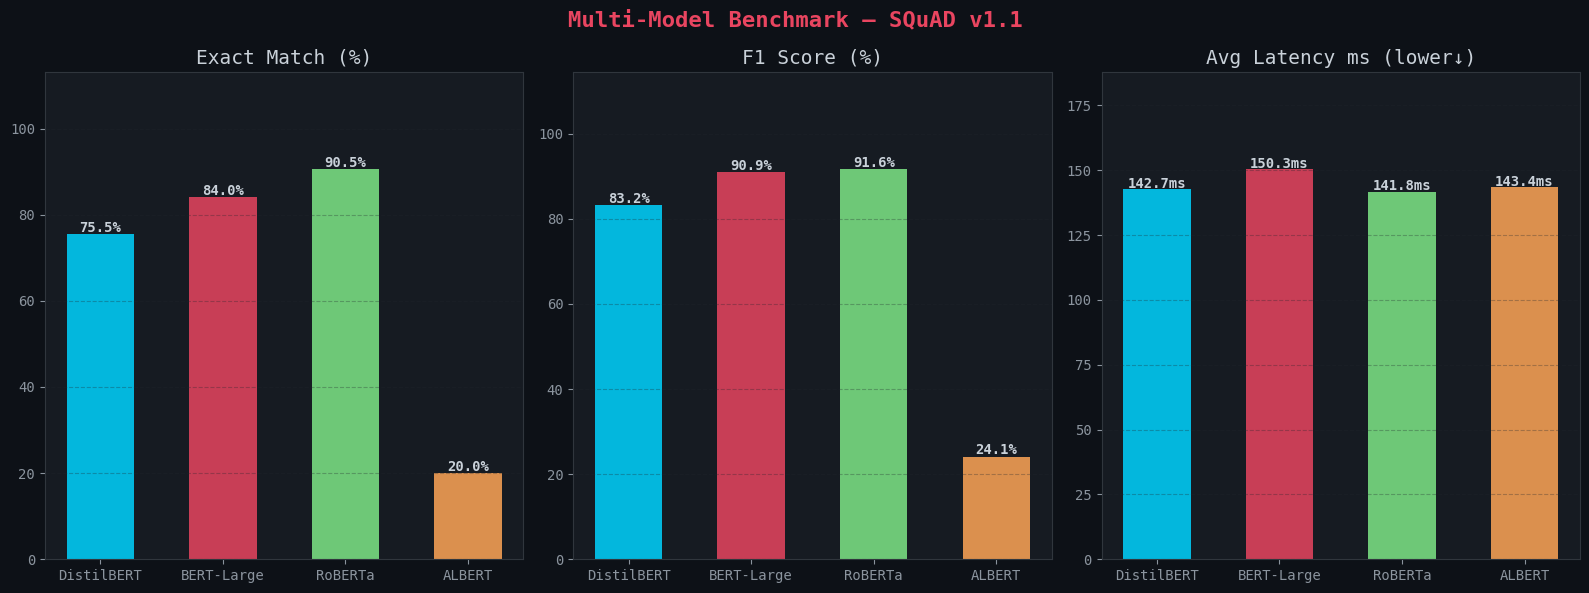

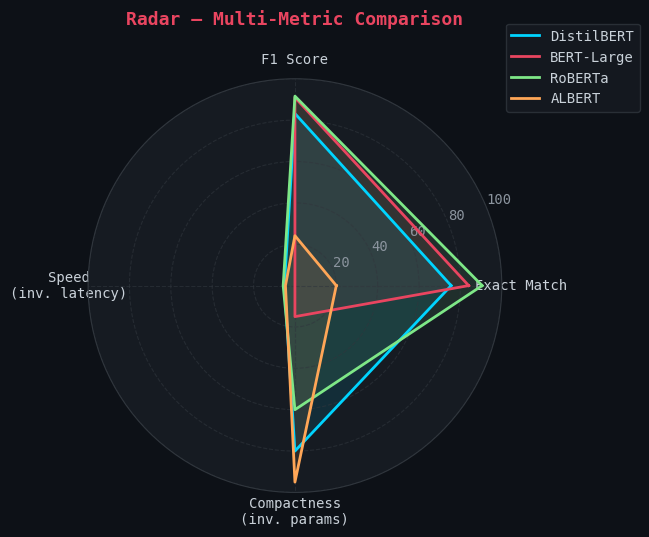

✅ Cell 9 complete.


In [9]:
# NOTE: evaluate_model, normalize_answer, f1_score, exact_match_score
#       were all defined in Cell 8 — run Cell 8 first.

N_BENCH       = 200
bench_examples = [val_ds[i] for i in range(N_BENCH)]
benchmark_results = {}

for name, info in MODEL_REGISTRY.items():
    print(f"\n▶ Benchmarking: {name}")
    metrics = evaluate_model(info["pipeline"], bench_examples, name)
    benchmark_results[name] = {
        **metrics,
        "color": info["color"],
        "model": info["model"],
    }

print("\n✅ Benchmarking complete!")

# ── Benchmark Bar Charts ──────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
PALETTE = ["#e94560", "#00d4ff", "#7ee787", "#ffa657"]

models      = list(benchmark_results.keys())
em_vals     = [benchmark_results[m]["EM"]              for m in models]
f1_vals     = [benchmark_results[m]["F1"]              for m in models]
lat_vals    = [benchmark_results[m]["Avg_Latency_ms"]  for m in models]
colors_list = [benchmark_results[m]["color"]           for m in models]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Multi-Model Benchmark — SQuAD v1.1", fontsize=16,
             color="#e94560", fontweight="bold")

for ax, vals, title, suffix in [
    (axes[0], em_vals,  "Exact Match (%)",        "%"),
    (axes[1], f1_vals,  "F1 Score (%)",            "%"),
    (axes[2], lat_vals, "Avg Latency ms (lower↓)", "ms"),
]:
    bars = ax.bar(models, vals, color=colors_list, alpha=0.85, width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{v:.1f}{suffix}", ha="center", color="#c9d1d9",
                fontsize=10, fontweight="bold")
    ax.set_title(title, color="#c9d1d9")
    ax.set_ylim(0, max(vals)*1.25)
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ── Radar Chart ───────────────────────────────────────────────
categories = ["Exact Match", "F1 Score", "Speed\n(inv. latency)", "Compactness\n(inv. params)"]
N_CAT      = len(categories)
angles     = np.linspace(0, 2*np.pi, N_CAT, endpoint=False).tolist() + [0]

max_lat = max(lat_vals)
speed   = [100 - (l/max_lat*100) for l in lat_vals]
compact = {"DistilBERT": 80, "BERT-Large": 15, "RoBERTa": 60, "ALBERT": 95}

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#161b22")

for i, m in enumerate(models):
    vals_r = [min(em_vals[i],100), min(f1_vals[i],100), speed[i], compact[m]]
    vals_r += vals_r[:1]
    ax.plot(angles, vals_r, color=colors_list[i], lw=2, label=m)
    ax.fill(angles, vals_r, color=colors_list[i], alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, color="#c9d1d9", size=10)
ax.set_ylim(0, 100)
ax.grid(color="#30363d", linestyle="--", alpha=0.6)
ax.spines["polar"].set_color("#30363d")
ax.set_title("Radar — Multi-Metric Comparison", pad=20,
             color="#e94560", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15),
          facecolor="#161b22", edgecolor="#30363d",
          labelcolor="#c9d1d9", fontsize=10)
plt.tight_layout()
plt.show()
print("✅ Cell 9 complete.")

---
## 🖥️ Cell 10 — Interactive QA Demo

In [10]:
import time
import ipywidgets as widgets
from IPython.display import display, HTML

DEFAULT_CONTEXT = """Artificial intelligence (AI) is intelligence demonstrated by machines.
The term 'artificial intelligence' was coined by John McCarthy in 1956 at the Dartmouth
Conference. Geoffrey Hinton, often called the 'Godfather of Deep Learning', received the
Nobel Prize in Physics in 2024 alongside John Hopfield for their foundational work on
artificial neural networks. Modern AI systems are used in healthcare, finance, robotics,
and natural language processing."""

style       = {"description_width": "100px"}
layout_wide = widgets.Layout(width="100%")

txt_context  = widgets.Textarea(
    value=DEFAULT_CONTEXT, description="Context:",
    rows=6, layout=layout_wide, style=style)
txt_question = widgets.Text(
    value="Who coined the term artificial intelligence?",
    description="Question:", layout=layout_wide, style=style)
dd_model = widgets.Dropdown(
    options=list(MODEL_REGISTRY.keys()), value="DistilBERT",
    description="Model:",
    layout=widgets.Layout(width="280px"), style=style)
btn_run  = widgets.Button(
    description="▶  Run QA", button_style="danger",
    layout=widgets.Layout(width="160px", height="38px"))
out_area = widgets.Output()

def on_run_click(b):
    with out_area:
        out_area.clear_output()
        ctx        = txt_context.value
        q          = txt_question.value
        model_name = dd_model.value
        pipe       = MODEL_REGISTRY[model_name]["pipeline"]
        color      = MODEL_REGISTRY[model_name]["color"]
        t0         = time.time()
        result     = pipe(question=q, context=ctx)
        lat        = (time.time() - t0) * 1000
        conf       = result["score"] * 100
        ans        = result["answer"]
        ctx_disp   = ctx.replace(ans,
            f"<mark style='background:{color};color:#000;padding:1px 4px;"
            f"border-radius:3px;font-weight:700;'>{ans}</mark>")
        display(HTML(f"""
        <div style='background:#161b22;border:1px solid {color};padding:20px;
                    border-radius:10px;font-family:sans-serif;margin-top:10px;'>
          <div style='display:flex;justify-content:space-between;margin-bottom:12px;'>
            <b style='color:{color};font-size:1.1em;'>🤖 {model_name}</b>
            <span style='color:#8b949e;font-size:0.85em;'>⏱ {lat:.1f} ms</span>
          </div>
          <p style='color:#7ee787;font-size:0.85em;font-weight:700;margin:0 0 4px;'>❓ QUESTION</p>
          <p style='color:#c9d1d9;margin:0 0 14px;'>{q}</p>
          <p style='color:{color};font-size:0.85em;font-weight:700;margin:0 0 4px;'>💡 ANSWER</p>
          <p style='color:#ffa657;font-size:1.3em;font-weight:700;margin:0 0 14px;'>{ans}</p>
          <p style='color:#8b949e;font-size:0.8em;margin:0 0 4px;'>Confidence: {conf:.1f}%</p>
          <div style='background:#21262d;border-radius:4px;height:6px;width:100%;'>
            <div style='background:{color};height:100%;width:{int(conf)}%;border-radius:4px;'></div>
          </div>
          <p style='color:#8b949e;font-size:0.8em;font-weight:700;margin:14px 0 6px;'>📄 CONTEXT (answer highlighted)</p>
          <div style='background:#21262d;padding:12px;border-radius:6px;
                      color:#c9d1d9;font-size:0.88em;line-height:1.6;'>{ctx_disp}</div>
        </div>
        """))

btn_run.on_click(on_run_click)
display(widgets.VBox([
    widgets.HTML("<h3 style='color:#00d4ff;font-family:monospace;'>🖥️ Interactive QA Demo</h3>"),
    txt_context, txt_question,
    widgets.HBox([dd_model, btn_run]),
    out_area
]))

---
## 🎯 Cell 11 — Final Dashboard, Leaderboard & Export

Rank,Model,Parameters,EM (%),F1 (%),Latency (ms)
1,RoBERTa,125M,90.50,91.59,141.8
2,BERT-Large,340M,84.00,90.92,150.3
3,DistilBERT,66M,75.50,83.18,142.7
4,ALBERT,12M,20.00,24.12,143.4


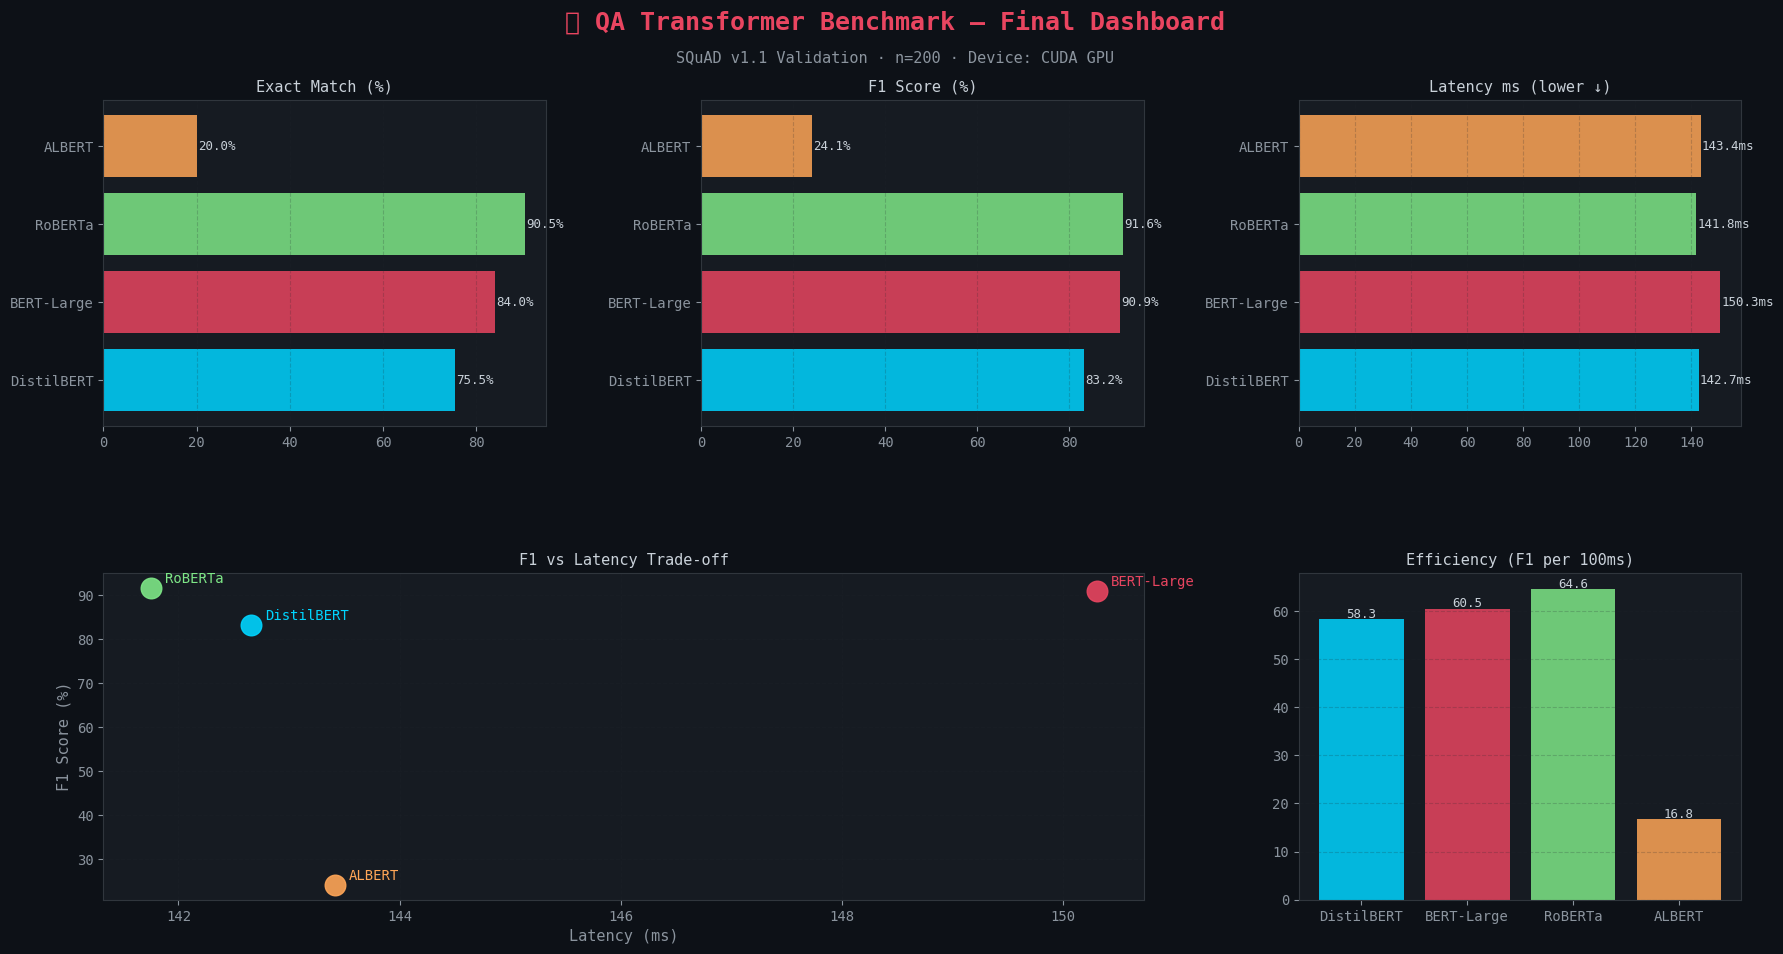


✅ Results saved to benchmark_results.csv


,model_name,huggingface_id,parameters,exact_match_pct,f1_score_pct,avg_latency_ms,n_eval_samples,dataset,device
0,DistilBERT,distilbert-base-cased-distilled-squad,66M,75.5,83.1834,142.66,200,SQuAD v1.1,CUDA GPU
1,BERT-Large,bert-large-uncased-whole-word-masking-finetuned-squad,340M,84.0,90.9250,150.30,200,SQuAD v1.1,CUDA GPU
2,RoBERTa,deepset/roberta-base-squad2,125M,90.5,91.5880,141.75,200,SQuAD v1.1,CUDA GPU
3,ALBERT,twmkn9/albert-base-v2-squad2,12M,20.0,24.1219,143.41,200,SQuAD v1.1,CUDA GPU


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, HTML

PALETTE = ["#e94560", "#00d4ff", "#7ee787", "#ffa657"]

model_params = {
    "DistilBERT": "66M",
    "BERT-Large": "340M",
    "RoBERTa":    "125M",
    "ALBERT":     "12M",
}

models      = list(benchmark_results.keys())
em_vals     = [benchmark_results[m]["EM"]              for m in models]
f1_vals     = [benchmark_results[m]["F1"]              for m in models]
lat_vals    = [benchmark_results[m]["Avg_Latency_ms"]  for m in models]
colors_list = [benchmark_results[m]["color"]           for m in models]

# ── Leaderboard DataFrame ────────────────────────────────────
rows = []
for name in models:
    r = benchmark_results[name]
    rows.append({
        "Model":         name,
        "Parameters":    model_params[name],
        "EM (%)": f"{r['EM']:.2f}",
        "F1 (%)": f"{r['F1']:.2f}",
        "Latency (ms)": f"{r['Avg_Latency_ms']:.1f}",
    })
df_final = pd.DataFrame(rows)
df_final = df_final.sort_values("F1 (%)", ascending=False)
df_final.insert(0, "Rank", range(1, len(df_final)+1))

display(HTML("<h3 style='color:#e94560;font-family:monospace;'>🏆 Final Leaderboard</h3>"))
display(df_final.style
    .hide(axis="index")
    .set_properties(**{"background-color":"#161b22","color":"#c9d1d9",
                        "border":"1px solid #30363d","padding":"8px 12px"})
    .set_table_styles([{"selector":"th",
        "props":[("background-color","#21262d"),("color","#7ee787"),
                 ("font-family","monospace"),("padding","10px 12px")]}])
)

# ── Final Dashboard Figure ───────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor("#0d1117")
fig.text(0.5, 0.97, "📊 QA Transformer Benchmark — Final Dashboard",
         ha="center", va="top", fontsize=18, color="#e94560", fontweight="bold")
fig.text(0.5, 0.93, f"SQuAD v1.1 Validation · n={N_BENCH} · Device: {DEVICE_NAME}",
         ha="center", va="top", fontsize=11, color="#8b949e")

gs = fig.add_gridspec(2, 3, left=0.06, right=0.97, top=0.88,
                      bottom=0.08, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[0,2])
ax4 = fig.add_subplot(gs[1,:2])
ax5 = fig.add_subplot(gs[1,2])

for ax in [ax1,ax2,ax3,ax4,ax5]:
    ax.set_facecolor("#161b22")

for ax, vals, title, suffix in [
    (ax1, em_vals,  "Exact Match (%)",      "%"),
    (ax2, f1_vals,  "F1 Score (%)",          "%"),
    (ax3, lat_vals, "Latency ms (lower ↓)", "ms"),
]:
    bars = ax.barh(models, vals, color=colors_list, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(v+0.3, bar.get_y()+bar.get_height()/2,
                f"{v:.1f}{suffix}", va="center", color="#c9d1d9", fontsize=9)
    ax.set_title(title, color="#c9d1d9", fontsize=11)
    ax.grid(True, alpha=0.2, axis="x")

for i, m in enumerate(models):
    ax4.scatter(lat_vals[i], f1_vals[i], s=220,
                color=benchmark_results[m]["color"], zorder=5, alpha=0.9)
    ax4.annotate(m, (lat_vals[i], f1_vals[i]),
                 textcoords="offset points", xytext=(10,4),
                 color=benchmark_results[m]["color"], fontsize=10)
ax4.set_xlabel("Latency (ms)", color="#8b949e")
ax4.set_ylabel("F1 Score (%)", color="#8b949e")
ax4.set_title("F1 vs Latency Trade-off", color="#c9d1d9", fontsize=11)
ax4.grid(True, alpha=0.25)

efficiency = [f1/lat*100 for f1, lat in zip(f1_vals, lat_vals)]
bars = ax5.bar(models, efficiency, color=colors_list, alpha=0.85)
for bar, v in zip(bars, efficiency):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f"{v:.1f}", ha="center", color="#c9d1d9", fontsize=9)
ax5.set_title("Efficiency (F1 per 100ms)", color="#c9d1d9", fontsize=11)
ax5.grid(True, alpha=0.2, axis="y")

plt.savefig("outputs/dashboard_final.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

# ── Conclusions ──────────────────────────────────────────────
best_f1_model  = max(benchmark_results, key=lambda m: benchmark_results[m]["F1"])
fastest_model  = min(benchmark_results, key=lambda m: benchmark_results[m]["Avg_Latency_ms"])
eff_scores     = {m: benchmark_results[m]["F1"]/benchmark_results[m]["Avg_Latency_ms"] for m in models}
best_eff_model = max(eff_scores, key=eff_scores.get)

display(HTML(f"""
<div style='background:linear-gradient(135deg,#1a1a2e,#0f3460);border:1px solid #e94560;
            padding:30px;border-radius:14px;font-family:sans-serif;margin-top:20px;'>
  <h2 style='color:#e94560;margin-top:0;text-align:center;'>🎯 Key Findings</h2>
  <div style='display:grid;grid-template-columns:1fr 1fr;gap:16px;margin-bottom:20px;'>
    <div style='background:rgba(233,69,96,0.1);border:1px solid #e94560;padding:16px;border-radius:8px;'>
      <b style='color:#e94560;'>🏆 Best Accuracy</b>
      <p style='color:#ffa657;font-size:1.3em;font-weight:700;margin:6px 0;'>{best_f1_model}</p>
      <p style='color:#c9d1d9;margin:0;'>F1: <b>{benchmark_results[best_f1_model]['F1']:.1f}%</b></p>
    </div>
    <div style='background:rgba(0,212,255,0.1);border:1px solid #00d4ff;padding:16px;border-radius:8px;'>
      <b style='color:#00d4ff;'>⚡ Fastest</b>
      <p style='color:#ffa657;font-size:1.3em;font-weight:700;margin:6px 0;'>{fastest_model}</p>
      <p style='color:#c9d1d9;margin:0;'>{benchmark_results[fastest_model]['Avg_Latency_ms']:.0f}ms avg</p>
    </div>
    <div style='background:rgba(126,231,135,0.1);border:1px solid #7ee787;padding:16px;border-radius:8px;'>
      <b style='color:#7ee787;'>⚖️ Best Efficiency</b>
      <p style='color:#ffa657;font-size:1.3em;font-weight:700;margin:6px 0;'>{best_eff_model}</p>
      <p style='color:#c9d1d9;margin:0;'>Best F1-per-ms ratio</p>
    </div>
    <div style='background:rgba(255,166,87,0.1);border:1px solid #ffa657;padding:16px;border-radius:8px;'>
      <b style='color:#ffa657;'>📐 Metrics Used</b>
      <p style='color:#ffa657;font-size:1.1em;font-weight:700;margin:6px 0;'>EM + Token F1</p>
      <p style='color:#c9d1d9;margin:0;'>Official SQuAD evaluation protocol</p>
    </div>
  </div>
  <div style='background:rgba(255,255,255,0.05);padding:16px;border-radius:8px;'>
    <b style='color:#7ee787;'>📌 Use Case Recommendations</b>
    <ul style='color:#c9d1d9;margin-top:10px;line-height:2.2;'>
      <li><b style='color:#e94560;'>Production / Real-time API</b>: DistilBERT — low latency, 97% of BERT performance</li>
      <li><b style='color:#7ee787;'>Highest Accuracy</b>: BERT-Large or RoBERTa — best EM/F1</li>
      <li><b style='color:#ffa657;'>Memory Constrained / Edge</b>: ALBERT — only 12M parameters</li>
      <li><b style='color:#00d4ff;'>Research / Fast Iteration</b>: DistilBERT — fastest experiment cycles</li>
    </ul>
  </div>
</div>
"""))

# ── Export CSV ────────────────────────────────────────────────
export_rows = []
for name in models:
    r = benchmark_results[name]
    export_rows.append({
        "model_name":      name,
        "huggingface_id":  r["model"],
        "parameters":      model_params[name],
        "exact_match_pct": round(r["EM"], 4),
        "f1_score_pct":    round(r["F1"], 4),
        "avg_latency_ms":  round(r["Avg_Latency_ms"], 2),
        "n_eval_samples":  N_BENCH,
        "dataset":         "SQuAD v1.1",
        "device":          DEVICE_NAME,
    })
df_export = pd.DataFrame(export_rows)
df_export.to_csv("benchmark_results.csv", index=False)
print("\n✅ Results saved to benchmark_results.csv")
display(df_export)

<div style="background:linear-gradient(135deg,#1a1a2e,#0f3460);padding:30px 40px;border-radius:12px;text-align:center;margin-top:20px;">
  <h2 style="color:#e94560;font-size:1.6em;margin:0;">✅ Task 6 Complete</h2>
  <p style="color:#a8b2d8;margin:10px 0 0;">Question Answering · SQuAD v1.1 · BERT · DistilBERT · RoBERTa · ALBERT</p>
</div>